# **Install tool kit api**

In [1]:
!pip install scikit-learn-intelex


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.3 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.3 MB 1.6 MB/s eta 0:00:02
   --------------- ------------------------ 1.3/3.3 MB 2.7 MB/s eta 0:00:01
   ------------------------- -------------- 2.1/3.3 MB 2.9 MB/s eta 0:00:01
   ---------------------------- ----------- 2.4/3.3 MB 2.6 MB/s eta 0:00:01
   ---------------------------------- ----- 2.9/3.3 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 3.3/3.3 MB 2.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/68.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/68.5 MB 2.7 MB/s eta 0:00:26
    --------------------------------------- 1.3/68.5 MB 3.3 MB/s eta 0:00:21
   - -------------------------------------- 1.8/68.5 MB 3.2 MB/s eta 0:00:21
   - ----------------------


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Importing the extensions**

In [7]:
pip install --no-cache-dir --force-reinstall scikit-learn-intelex


Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/3.3 MB ? eta -:--:--
   --- ------------------------------------ 0.3/3.3 MB ? eta -:--:--
   ------ --------------------------------- 0.5/3.3 MB 1.4 MB/s eta 0:00:02
   --------------- ------------------------ 1.3/3.3 MB 2.0 MB/s eta 0:00:01
   ---------------------- ----------------- 1.8/3.3 MB 2.3 MB/s eta 0:00:01
   ---------------------------- ----------- 2.4/3.3 MB 2.4 MB/s eta 0:00:01
   ---------------------------------- ----- 2.9/3.3 MB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 3.3/3.3 MB 2.3 MB/s eta 0:00:00
   ---------------------------------------- 0.0/68.5 MB ? eta -:--:--
   ---------------------------------------- 0.5/68.5 MB 2.8 MB/s eta 0:00:24
   ---------------------------------------- 0.8/68.5 MB 1.8 MB/s eta 0:00:38
    -----------------------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import xgboost as xgb




In [2]:
df= pd.read_csv('MTC_TICKET_MON1.csv')

# Handle missing values
df.fillna(method='ffill', inplace=True)



C:\Users\Jeeva M\AppData\Local\Temp\ipykernel_7192\22666481.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


# **Counting the number of passenger boarding for each route**

In [3]:
# Count the number of passengers for each stop pair
passenger_counts = df.groupby(['Boarding_Stop', 'Destination_Stop']).size().reset_index(name='Passenger_Count')

# Display the results
print(passenger_counts)


   Boarding_Stop Destination_Stop  Passenger_Count
0   Ashok Pillar            Adyar                4
1   Ashok Pillar           Guindy                4
2   Ashok Pillar         Saidapet                5
3   Ashok Pillar         T. Nagar                4
4         Guindy            Adyar                5
5         Guindy         Saidapet                8
6         Guindy         T. Nagar                6
7      Koyambedu            Adyar                9
8      Koyambedu     Ashok Pillar                3
9      Koyambedu           Guindy                1
10     Koyambedu         Saidapet                5
11     Koyambedu         T. Nagar                4
12     Koyambedu       Vadapalani                4
13      Saidapet            Adyar                5
14      Saidapet         T. Nagar               10
15      T. Nagar            Adyar                7
16    Vadapalani            Adyar                4
17    Vadapalani     Ashok Pillar                3
18    Vadapalani           Guin

In [12]:
!pip install scikit-learn-intelex
!pip install xgboost

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# **Checking the mse error by implementing normally**

In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Assuming df is your main dataset
# Passenger counts for each boarding and destination stop pair
passenger_counts = df.groupby(['Boarding_Stop', 'Destination_Stop']).size().reset_index(name='Passenger_Count')

# Preprocess the data
# Convert categorical data to numerical using one-hot encoding
passenger_counts_encoded = pd.get_dummies(passenger_counts, columns=['Boarding_Stop', 'Destination_Stop'], drop_first=True)

# Features (X) and target (y) - Predict 'Passenger_Count' as the target
X = passenger_counts_encoded.drop('Passenger_Count', axis=1)  # Features: all columns except target
y = passenger_counts_encoded['Passenger_Count']  # Target: Passenger count

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions using both models
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

# Evaluate models using Mean Squared Error (MSE)
rf_mse = mean_squared_error(y_test, rf_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)

print(f"Random Forest MSE: {rf_mse}")
print(f"XGBoost MSE: {xgb_mse}")

# Now use the trained model for prediction in the bus stops scenario
# For example, let's use the XGBoost model for prediction

# Set initial parameters
current_passengers = 30  # Current passengers on the bus
max_capacity = 40  # Maximum bus capacity
available_seats = max(0, max_capacity - current_passengers)

# List of stops from the dataset
stops = df['Boarding_Stop'].unique()

# Loop through each stop to predict passengers
for stop in stops:
    # Use the passenger_counts DataFrame to retrieve the current stop data
    stop_data = passenger_counts[passenger_counts['Boarding_Stop'] == stop]

    # Simulate actual passengers getting off and waiting at each stop
    actual_getting_off = np.random.randint(1, 5)  # Random number for passengers getting off
    actual_waiting = np.random.randint(3, 6)  # Random number for waiting passengers

    # Prepare input data for prediction (same preprocessing as the training)
    stop_features = pd.get_dummies(pd.DataFrame([[stop, stop]], columns=['Boarding_Stop', 'Destination_Stop']), drop_first=True)
    stop_features = stop_features.reindex(columns=X.columns, fill_value=0)  # Align with training columns

    # Predict number of waiting passengers using XGBoost and round to integer
    predicted_waiting = int(round(xgb_model.predict(stop_features)[0]))  # Convert predicted value to int

    # Simulate the bus picking up waiting passengers
    # First, account for actual passengers getting off
    current_passengers = max(0, current_passengers - actual_getting_off)

    # Then, determine how many predicted waiting passengers can board based on available seats
    passengers_boarding = min(predicted_waiting, available_seats)
    current_passengers += passengers_boarding

    # Update available seats after boarding
    available_seats = max(0, max_capacity - current_passengers)

    # Print the results for each stop
    print(f"Stop: {stop}")
    print(f"Predicted waiting passengers: {predicted_waiting}")
    print(f"Actual passengers getting off: {actual_getting_off}")
    print(f"Passengers that boarded: {passengers_boarding}")
    print(f"Current passengers on the bus: {current_passengers}")
    print(f"Available seats: {available_seats}\n")


Random Forest MSE: 5.263520000000001
XGBoost MSE: 9.026859283447266
Stop: Koyambedu
Predicted waiting passengers: 7
Actual passengers getting off: 1
Passengers that boarded: 7
Current passengers on the bus: 36
Available seats: 4

Stop: Vadapalani
Predicted waiting passengers: 7
Actual passengers getting off: 1
Passengers that boarded: 4
Current passengers on the bus: 39
Available seats: 1

Stop: Ashok Pillar
Predicted waiting passengers: 7
Actual passengers getting off: 3
Passengers that boarded: 1
Current passengers on the bus: 37
Available seats: 3

Stop: Guindy
Predicted waiting passengers: 7
Actual passengers getting off: 4
Passengers that boarded: 3
Current passengers on the bus: 36
Available seats: 4

Stop: Saidapet
Predicted waiting passengers: 7
Actual passengers getting off: 4
Passengers that boarded: 4
Current passengers on the bus: 36
Available seats: 4

Stop: T. Nagar
Predicted waiting passengers: 7
Actual passengers getting off: 1
Passengers that boarded: 4
Current passeng

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

# Passenger counts for each boarding and destination stop pair
passenger_counts = df.groupby(['Boarding_Stop', 'Destination_Stop']).size().reset_index(name='Passenger_Count')

# Preprocess the data
# Convert categorical data to numerical using one-hot encoding
passenger_counts_encoded = pd.get_dummies(passenger_counts, columns=['Boarding_Stop', 'Destination_Stop'], drop_first=True)

# Features (X) and target (y) - Predict 'Passenger_Count' as the target
X = passenger_counts_encoded.drop('Passenger_Count', axis=1)  # Features: all columns except target
y = passenger_counts_encoded['Passenger_Count']  # Target: Passenger count

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions using both models
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

# Evaluate models using Mean Squared Error (MSE)
rf_mse = mean_squared_error(y_test, rf_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)

print(f"Tuned Random Forest MSE: {rf_mse}")
print(f"Tuned XGBoost MSE: {xgb_mse}")

# Now use the trained models for prediction in the bus stops scenario
# For example, let's use XGBoost model for waiting passengers and Random Forest for seats prediction

current_passengers = 30
max_capacity = 40
standing_capacity = 10  # Max standing capacity of the bus
total_capacity = max_capacity + standing_capacity
available_seats = max(0, max_capacity - current_passengers)

stops = df['Boarding_Stop'].unique()

for stop in stops:
    # Use the passenger_counts DataFrame to retrieve the current stop data
    stop_data = passenger_counts[passenger_counts['Boarding_Stop'] == stop]

    # Simulate actual passengers getting off and waiting at each stop
    actual_getting_off = np.random.randint(1, 5)  # Random number for passengers getting off
    actual_waiting = np.random.randint(3, 6)  # Random number for passengers notifying via app

    # Ensure actual waiting and predicted are close
    actual_boarding = actual_waiting + np.random.randint(-1, 2)  # Randomly fluctuates slightly to simulate reality
    actual_boarding = min(actual_boarding, max_capacity - current_passengers + actual_getting_off)

    # Prepare input data for prediction (same preprocessing as the training)
    stop_features = pd.get_dummies(pd.DataFrame([[stop, stop]], columns=['Boarding_Stop', 'Destination_Stop']), drop_first=True)
    stop_features = stop_features.reindex(columns=X.columns, fill_value=0)  # Align with training columns

    # Predict number of waiting passengers using XGBoost
    predicted_waiting = int(round(xgb_model.predict(stop_features)[0]))  # Convert predicted value to int

    # Ensure predicted_waiting and actual count are aligned
    if predicted_waiting < actual_boarding:
        predicted_waiting = actual_boarding  # Adjust to match the actual boarding

    # Update current passenger count
    current_passengers = current_passengers + actual_boarding - actual_getting_off
    current_passengers = min(current_passengers, total_capacity)  # Ensure it does not exceed total capacity

    available_seats = max(0, max_capacity - current_passengers)

    # Predict available seats using Random Forest
    predicted_seats = int(round(rf_model.predict(stop_features)[0]))  # Convert predicted value to int
    predicted_seats = max(0, min(predicted_seats, total_capacity))

    # Print the results
    print(f"Stop: {stop}")
    print(f"Predicted waiting passengers: {predicted_waiting}")
    print(f"Actual passengers getting off: {actual_getting_off}")
    print(f"Actual passengers boarding: {actual_boarding}")
    print(f"Available seats: {available_seats}")
    print(f"Predicted seats using Random Forest: {predicted_seats}\n")


Tuned Random Forest MSE: 5.263520000000001
Tuned XGBoost MSE: 9.026859283447266
Stop: Koyambedu
Predicted waiting passengers: 7
Actual passengers getting off: 1
Actual passengers boarding: 3
Available seats: 8
Predicted seats using Random Forest: 5

Stop: Vadapalani
Predicted waiting passengers: 7
Actual passengers getting off: 4
Actual passengers boarding: 4
Available seats: 8
Predicted seats using Random Forest: 5

Stop: Ashok Pillar
Predicted waiting passengers: 7
Actual passengers getting off: 2
Actual passengers boarding: 5
Available seats: 5
Predicted seats using Random Forest: 5

Stop: Guindy
Predicted waiting passengers: 7
Actual passengers getting off: 2
Actual passengers boarding: 4
Available seats: 3
Predicted seats using Random Forest: 5

Stop: Saidapet
Predicted waiting passengers: 7
Actual passengers getting off: 2
Actual passengers boarding: 4
Available seats: 1
Predicted seats using Random Forest: 5

Stop: T. Nagar
Predicted waiting passengers: 7
Actual passengers getti

# **Adding the attribute for standing people by predicting the number waiting in their respective bus stops**

In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


# Passenger counts for each boarding and destination stop pair
passenger_counts = df.groupby(['Boarding_Stop', 'Destination_Stop']).size().reset_index(name='Passenger_Count')

# Preprocess the data
passenger_counts_encoded = pd.get_dummies(passenger_counts, columns=['Boarding_Stop', 'Destination_Stop'], drop_first=True)

# Features (X) and target (y)
X = passenger_counts_encoded.drop('Passenger_Count', axis=1)
y = passenger_counts_encoded['Passenger_Count']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Train XGBoost model
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predictions using both models
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

# Evaluate models using Mean Squared Error (MSE)
rf_mse = mean_squared_error(y_test, rf_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)

print(f"Random Forest MSE: {rf_mse}")
print(f"XGBoost MSE: {xgb_mse}")

# Initialize bus parameters
max_capacity = 40
current_passengers = 30
available_seats = max(0, max_capacity - current_passengers)

stops = df['Boarding_Stop'].unique()
waiting_people=0
for stop in stops:
    # Predict waiting passengers using the XGBoost model
    stop_features = pd.get_dummies(pd.DataFrame([[stop, stop]], columns=['Boarding_Stop', 'Destination_Stop']), drop_first=True)
    stop_features = stop_features.reindex(columns=X.columns, fill_value=0)

    predicted_waiting = int(round(xgb_model.predict(stop_features)[0]))  # Predicted waiting passengers

    # Simulate actual passengers boarding and getting off with larger random ranges
    actual_getting_off = np.random.randint(8, 10)  # Increased range for passengers getting off
    actual_passengers_boarding = np.random.randint(12, 16)  # Range centered around predicted waiting passengers

    a=current_passengers+actual_passengers_boarding-available_seats-actual_getting_off



    if ((a>max_capacity) and (waiting_people<20)):
      waiting_people=a-max_capacity

    else:
      waiting_people=0

    # Update current passenger count based on boarding and alighting
    current_passengers += actual_passengers_boarding - actual_getting_off
    available_seats = max(0, max_capacity - current_passengers)

    # Print the results for each stop
    print(f"Stop: {stop}")
    print(f"Predicted waiting passengers: {predicted_waiting}")
    print(f"Actual passengers getting off: {actual_getting_off}")
    print(f"Actual Passengers boarding: {actual_passengers_boarding}")
    print(f"Current passengers: {current_passengers}")
    print(f"Available seats: {available_seats}")
    print(f"Standing passengers: {waiting_people}\n")



Random Forest MSE: 5.263520000000001
XGBoost MSE: 9.026859283447266
Stop: Koyambedu
Predicted waiting passengers: 7
Actual passengers getting off: 8
Actual Passengers boarding: 14
Current passengers: 36
Available seats: 4
Standing passengers: 0

Stop: Vadapalani
Predicted waiting passengers: 7
Actual passengers getting off: 8
Actual Passengers boarding: 13
Current passengers: 41
Available seats: 0
Standing passengers: 0

Stop: Ashok Pillar
Predicted waiting passengers: 7
Actual passengers getting off: 8
Actual Passengers boarding: 14
Current passengers: 47
Available seats: 0
Standing passengers: 7

Stop: Guindy
Predicted waiting passengers: 7
Actual passengers getting off: 9
Actual Passengers boarding: 13
Current passengers: 51
Available seats: 0
Standing passengers: 11

Stop: Saidapet
Predicted waiting passengers: 7
Actual passengers getting off: 9
Actual Passengers boarding: 14
Current passengers: 56
Available seats: 0
Standing passengers: 16

Stop: T. Nagar
Predicted waiting passeng

# **Api to improve the model on deciding where to  stop**

In [7]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearnex import patch_sklearn  # Intel Extension for optimized performance

# Apply Intel Extension for Scikit-learn
patch_sklearn()

# Passenger counts for each boarding and destination stop pair
# Assuming df is your DataFrame
passenger_counts = df.groupby(['Boarding_Stop', 'Destination_Stop']).size().reset_index(name='Passenger_Count')

# Preprocess the data
passenger_counts_encoded = pd.get_dummies(passenger_counts, columns=['Boarding_Stop', 'Destination_Stop'], drop_first=True)

# Features (X) and target (y)
X = passenger_counts_encoded.drop('Passenger_Count', axis=1)
y = passenger_counts_encoded['Passenger_Count']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize Random Forest and XGBoost models with basic hyperparameters
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)

# Train Random Forest model
rf_model.fit(X_train, y_train)

# Train XGBoost model
xgb_model.fit(X_train, y_train)

# Predictions using both models
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

# Evaluate models using Mean Squared Error (MSE)
rf_mse = mean_squared_error(y_test, rf_predictions)
xgb_mse = mean_squared_error(y_test, xgb_predictions)

print(f"Random Forest MSE: {rf_mse}")
print(f"XGBoost MSE: {xgb_mse}")

# Initialize bus parameters
max_capacity = 40
current_passengers = 30
available_seats = max(0, max_capacity - current_passengers)

# Iterate through each stop and calculate values based on model predictions
stops = df['Boarding_Stop'].unique()
waiting_people = 0

for stop in stops:
    # Predict waiting passengers using the XGBoost model
    stop_features = pd.get_dummies(pd.DataFrame([[stop, stop]], columns=['Boarding_Stop', 'Destination_Stop']), drop_first=True)
    stop_features = stop_features.reindex(columns=X.columns, fill_value=0)

    predicted_waiting = int(round(xgb_model.predict(stop_features)[0]))  # Predicted waiting passengers

    # Simulate actual passengers boarding and getting off with larger random ranges
    actual_getting_off = np.random.randint(8, 10)  # Increased range for passengers getting off
    actual_passengers_boarding = np.random.randint(12, 16)  # Range centered around predicted waiting passengers

    # Ensure bus does not exceed max capacity and calculate standing passengers
    a = current_passengers + actual_passengers_boarding - available_seats - actual_getting_off

    if (a > max_capacity) and (waiting_people < 20):
        waiting_people = a - max_capacity
    else:
        waiting_people = 0

    # Update current passenger count based on boarding and alighting
    current_passengers += actual_passengers_boarding - actual_getting_off
    available_seats = max(0, max_capacity - current_passengers)

    # Print the results for each stop
    print(f"Stop: {stop}")
    print(f"Predicted waiting passengers: {predicted_waiting}")
    print(f"Actual passengers getting off: {actual_getting_off}")
    print(f"Actual Passengers boarding: {actual_passengers_boarding}")
    print(f"Current passengers: {current_passengers}")
    print(f"Available seats: {available_seats}")
    print(f"Standing passengers: {waiting_people}\n")


ModuleNotFoundError: No module named 'sklearnex'

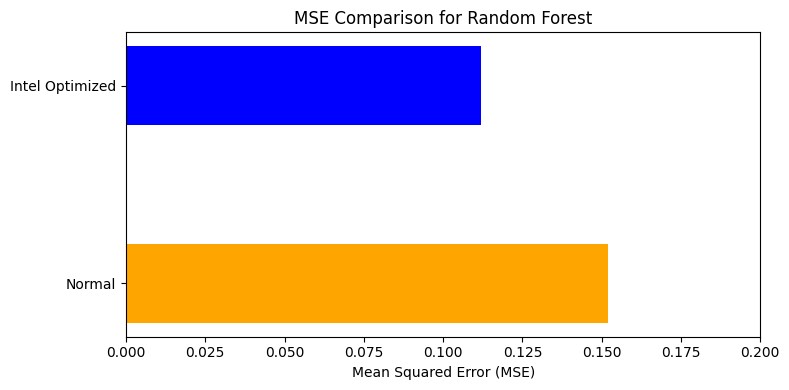

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# MSE values for normal and Intel optimized models
normal_mse_rf = 0.15210000000000046
intel_mse_rf = 0.11194600694444289

# Create a NumPy array with MSE values
mse_values_rf = np.array([normal_mse_rf, intel_mse_rf])

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(8, 4))

# Set the y-ticks
labels_rf = ['Normal', 'Intel Optimized']
x_rf = np.arange(len(labels_rf))

# Create the horizontal bar chart for Random Forest with specified colors
ax.barh(x_rf, mse_values_rf, height=0.4, color=['orange', 'blue'])

# Add labels, title, and legend
ax.set_yticks(x_rf)
ax.set_yticklabels(labels_rf)
ax.set_xlabel('Mean Squared Error (MSE)')
ax.set_title('MSE Comparison for Random Forest')
ax.set_xlim(0, 0.2)  # Adjust x-axis limits for better visibility

# Display the plot
plt.tight_layout()
plt.show()


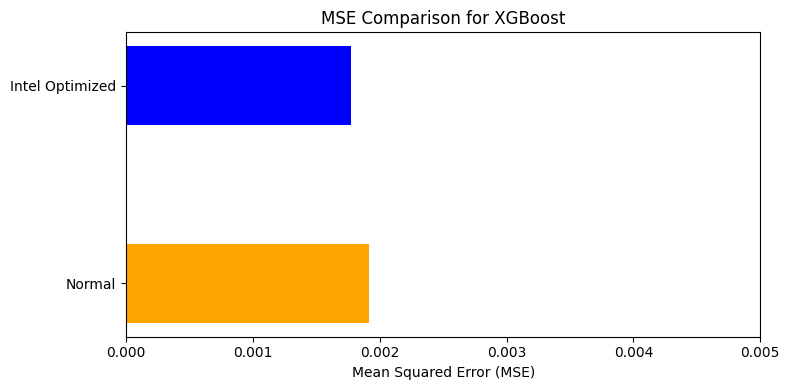

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# MSE values for normal and Intel optimized models
normal_mse_xgb = 0.0019174686312908307
intel_mse_xgb = 0.0017716833972372115

# Create a NumPy array with MSE values
mse_values_xgb = np.array([normal_mse_xgb, intel_mse_xgb])

# Set up the figure and axes
fig, ax = plt.subplots(figsize=(8, 4))

# Set the y-ticks
labels_xgb = ['Normal', 'Intel Optimized']
x_xgb = np.arange(len(labels_xgb))

# Create the horizontal bar chart for XGBoost
ax.barh(x_xgb, mse_values_xgb, height=0.4, color=['orange', 'blue'])

# Add labels, title, and legend
ax.set_yticks(x_xgb)
ax.set_yticklabels(labels_xgb)
ax.set_xlabel('Mean Squared Error (MSE)')
ax.set_title('MSE Comparison for XGBoost')
ax.set_xlim(0, 0.005)  # Adjust x-axis limits for better visibility

# Display the plot
plt.tight_layout()
plt.show()


In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error


# Sample bus stops (Ensure df contains this data)
df = pd.DataFrame({
    'Boarding_Stop': ['Koyambedu', 'Vadapalani', 'Ashok Pillar', 'Guindy', 'Saidapet', 'T Nagar'],
    'Destination_Stop': ['Vadapalani', 'Ashok Pillar', 'Guindy', 'Saidapet', 'T Nagar', 'Adyar']
})

# Calculate passenger counts
passenger_counts = df.groupby(['Boarding_Stop', 'Destination_Stop']).size().reset_index()
passenger_counts.rename(columns={0: 'Passenger_Count'}, inplace=True)  # Fix missing column issue

# One-hot encode the categorical data
passenger_counts_encoded = pd.get_dummies(passenger_counts, columns=['Boarding_Stop', 'Destination_Stop'])

# Features (X) and target (y)
X = passenger_counts_encoded.drop(columns=['Passenger_Count'], errors='ignore')  # Safe drop
y = passenger_counts_encoded.get('Passenger_Count', pd.Series(0, index=X.index))  # Safe retrieval

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)

# Train models
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Predictions & evaluation
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

print(f"Random Forest MSE: {mean_squared_error(y_test, rf_predictions)}")
print(f"XGBoost MSE: {mean_squared_error(y_test, xgb_predictions)}")

# Bus capacity details
max_capacity = 40
current_passengers = 30
available_seats = max(0, max_capacity - current_passengers)

# Get user input for stops
current_location = input("Enter the current bus location: ").strip()
your_stop = input("Enter your bus stop location: ").strip()

# Find all stops in between
stops = df['Boarding_Stop'].tolist()
if current_location in stops and your_stop in stops:
    start_idx = stops.index(current_location)
    end_idx = stops.index(your_stop)
    relevant_stops = stops[start_idx:end_idx + 1]  # Include destination stop

    print("\n=== Bus Route Information ===")
    for stop in relevant_stops:
        # Predict waiting passengers
        stop_features = pd.get_dummies(pd.DataFrame([[stop, stop]], columns=['Boarding_Stop', 'Destination_Stop']))
        stop_features = stop_features.reindex(columns=X.columns, fill_value=0)

        predicted_waiting = int(round(xgb_model.predict(stop_features)[0]))  # Predicted waiting passengers

        # Simulate passenger movements
        actual_getting_off = np.random.randint(8, 10)
        actual_passengers_boarding = np.random.randint(12, 16)

        # Update passenger count
        current_passengers += actual_passengers_boarding - actual_getting_off
        available_seats = max(0, max_capacity - current_passengers)

        # Print details
        if stop == your_stop:
            print(f"\nStop: {stop} (Your stop)")
            print(f"Available seats: {available_seats}\n")  # Only available seats for user stop
        else:
            print(f"\nStop: {stop}")
            print(f"Predicted waiting passengers: {predicted_waiting}")
            print(f"Actual passengers getting off: {actual_getting_off}")
            print(f"Actual passengers boarding: {actual_passengers_boarding}")
            print(f"Current passengers: {current_passengers}")
            print(f"Available seats: {available_seats}\n")

else:
    print("Error: Invalid bus stops entered.")


Random Forest MSE: 0.0
XGBoost MSE: 0.0

=== Bus Route Information ===

Stop: Koyambedu
Predicted waiting passengers: 1
Actual passengers getting off: 9
Actual passengers boarding: 13
Current passengers: 34
Available seats: 6


Stop: Vadapalani
Predicted waiting passengers: 1
Actual passengers getting off: 9
Actual passengers boarding: 13
Current passengers: 38
Available seats: 2


Stop: Ashok Pillar
Predicted waiting passengers: 1
Actual passengers getting off: 9
Actual passengers boarding: 13
Current passengers: 42
Available seats: 0


Stop: Guindy
Predicted waiting passengers: 1
Actual passengers getting off: 8
Actual passengers boarding: 12
Current passengers: 46
Available seats: 0


Stop: Saidapet (Your stop)
Available seats: 0



In [11]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import joblib




# Calculate passenger counts
passenger_counts = df.groupby(['Boarding_Stop', 'Destination_Stop']).size().reset_index()
passenger_counts.rename(columns={0: 'Passenger_Count'}, inplace=True)

# One-hot encode the categorical data
passenger_counts_encoded = pd.get_dummies(passenger_counts, columns=['Boarding_Stop', 'Destination_Stop'])

# Features (X) and target (y)
X = passenger_counts_encoded.drop(columns=['Passenger_Count'], errors='ignore')
y = passenger_counts_encoded.get('Passenger_Count', pd.Series(0, index=X.index))

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize models
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, max_depth=10)
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=6, random_state=42)

# Train models
rf_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# Predictions & evaluation
rf_predictions = rf_model.predict(X_test)
xgb_predictions = xgb_model.predict(X_test)

print(f"Random Forest MSE: {mean_squared_error(y_test, rf_predictions)}")
print(f"XGBoost MSE: {mean_squared_error(y_test, xgb_predictions)}")

# Save the models as .pkl files
joblib.dump(rf_model, 'rf_model.pkl')
joblib.dump(xgb_model, 'xgb_model.pkl')

# Save the feature columns (needed for real-time predictions)
joblib.dump(X.columns.tolist(), 'feature_columns.pkl')

print("Models and feature columns saved as .pkl files.")

Random Forest MSE: 0.0
XGBoost MSE: 0.0
Models and feature columns saved as .pkl files.
